In [ ]:
import pandas as pd
from sklearn.datasets import load_diabetes

# Load sample dataset (Diabetes)
data = load_diabetes()
X = data.data
y = data.target

# Create DataFrame for display
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


# Model Validation Techniques

Model validation is the process of evaluating how well your model performs on unseen data. It helps prevent overfitting and ensures the model's generalizability.

In this notebook, we will explore:
- Holdout Validation
- K-Fold Cross-Validation
- Stratified K-Fold
- Leave-One-Out Cross-Validation
- Repeated K-Fold


## Holdout Validation – Data Splitting

In holdout validation, we randomly divide the dataset into two disjoint sets:

- **Training Set**: Used to train the model.
- **Test Set**: Used to evaluate the model's performance on unseen data.

Let’s visualize how the target variable (`y`) is distributed across these sets to ensure the split retains the underlying data characteristics.


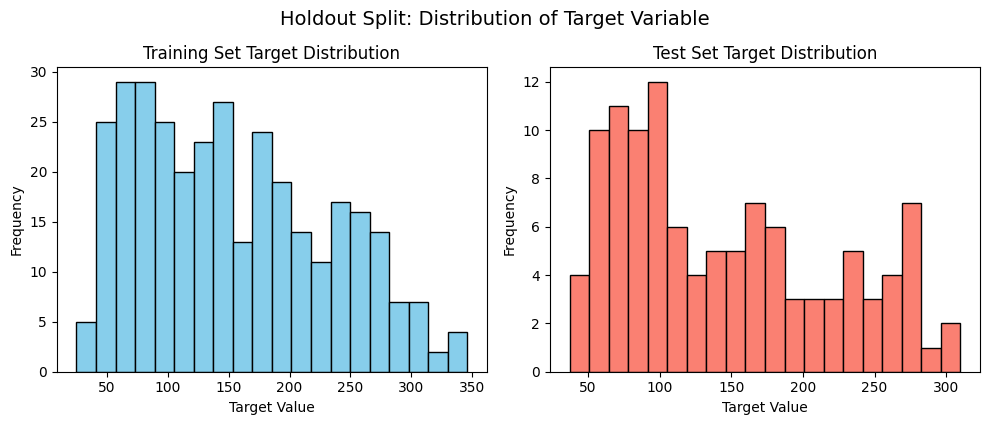

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Plot distributions
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(y_train, bins=20, color='skyblue', edgecolor='black')
plt.title("Training Set Target Distribution")
plt.xlabel("Target Value")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
plt.hist(y_test, bins=20, color='salmon', edgecolor='black')
plt.title("Test Set Target Distribution")
plt.xlabel("Target Value")
plt.ylabel("Frequency")

plt.tight_layout()
plt.suptitle("Holdout Split: Distribution of Target Variable", fontsize=14, y=1.05)
plt.show()


## K-Fold Cross-Validation – Understanding the Split

In **K-Fold Cross-Validation**, the dataset is split into `K` equal (or nearly equal) parts (called "folds").

Here's how it works:
- The model is trained on `K-1` folds and validated on the remaining fold.
- This is repeated `K` times, with each fold used exactly once as the validation set.
- The final performance is averaged across all folds, reducing bias from a single split.

Let’s visualize how the target variable (`y`) is distributed across each fold. This is important to confirm that each fold captures the diversity of the full dataset.


In [ ]:
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
import numpy as np

# Use KFold to generate split indices
kf = KFold(n_splits=5, shuffle=True, random_state=42)
folds = list(kf.split(X))

folds

[(array([  1,   2,   3,   4,   5,   6,   7,   8,  10,  12,  13,  14,  16,
          17,  18,  20,  21,  23,  26,  27,  28,  29,  31,  32,  34,  35,
          36,  37,  38,  40,  41,  43,  44,  45,  47,  48,  49,  50,  51,
          52,  53,  54,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,
          68,  69,  71,  74,  80,  81,  83,  84,  85,  86,  87,  88,  89,
          91,  92,  94,  95,  96,  97,  98,  99, 100, 102, 103, 105, 106,
         107, 108, 109, 110, 111, 112, 114, 115, 118, 119, 120, 121, 122,
         123, 124, 125, 127, 128, 129, 130, 133, 134, 135, 136, 137, 138,
         139, 141, 142, 143, 144, 145, 146, 147, 149, 150, 151, 152, 153,
         154, 156, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
         169, 170, 171, 173, 174, 175, 177, 178, 179, 180, 182, 183, 184,
         186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 197, 198, 200,
         201, 202, 204, 205, 206, 207, 208, 210, 212, 213, 214, 215, 216,
         217, 219, 220, 221, 222, 223,

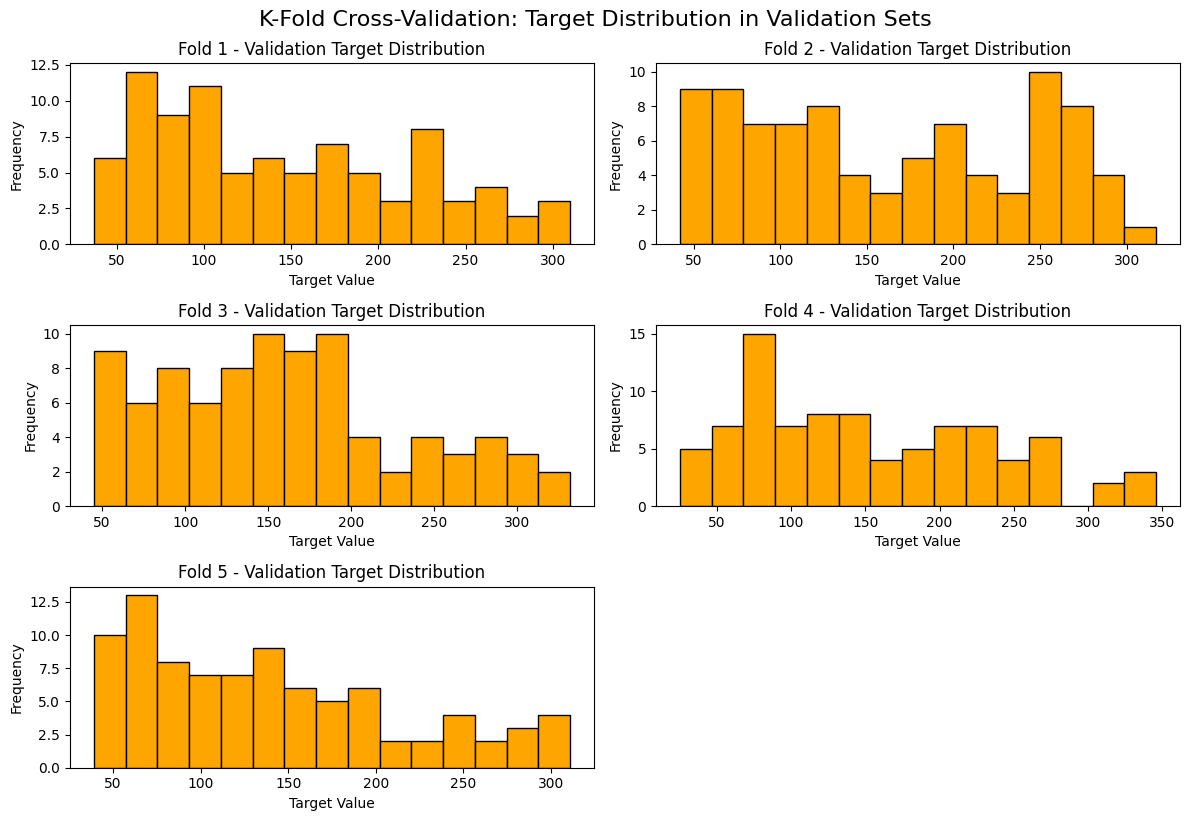

In [ ]:
# Visualize distribution of target values per fold
plt.figure(figsize=(12, 8))

for i, (train_idx, val_idx) in enumerate(folds):
    y_val = y[val_idx]
    plt.subplot(3, 2, i+1)
    plt.hist(y_val, bins=15, color='orange', edgecolor='black')
    plt.title(f"Fold {i+1} - Validation Target Distribution")
    plt.xlabel("Target Value")
    plt.ylabel("Frequency")

plt.tight_layout()
plt.suptitle("K-Fold Cross-Validation: Target Distribution in Validation Sets", fontsize=16, y=1.02)
plt.show()


### **Explanation of Code & Output Justification**

* **`KFold(n_splits=5)`**: Divides the dataset into 5 subsets.
* **`shuffle=True`**: Ensures that data is randomly shuffled before splitting (important for balanced folds).
* **Visualization**: For each fold, we extract the validation indices and plot the histogram of the target variable.
* **Justification**:

  * Ensures **each fold sees the diversity** in target variable.
  * Confirms there's no heavy bias introduced by an imbalanced split.
  * Provides **intuitive understanding** of what K-Fold does behind the scenes.


## Stratified K-Fold Cross-Validation – Preserving Class Balance

In classification tasks, it is important that each fold maintains the **same proportion of class labels** as the original dataset.

This is where **Stratified K-Fold Cross-Validation** is useful. It splits the dataset such that:
- Each fold has approximately the same percentage of samples for each class.
- Prevents class imbalance issues in training and validation.

Let’s demonstrate this by visualizing how class distribution looks in each fold using a classification dataset.


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np

# Load classification dataset
data = load_breast_cancer()
X_class = data.data
y_class = data.target
class_names = data.target_names

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
folds = list(skf.split(X_class, y_class))
folds

[(array([  1,   2,   3,   4,   5,   6,   7,   9,  10,  11,  12,  13,  15,
          16,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,  28,  30,
          32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
          45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  56,  57,  58,
          59,  60,  62,  63,  64,  66,  67,  68,  69,  71,  72,  73,  74,
          78,  81,  82,  83,  85,  87,  89,  91,  92,  93,  94,  95,  96,
          97,  98,  99, 100, 101, 102, 103, 105, 107, 108, 109, 110, 113,
         116, 120, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
         134, 135, 136, 137, 139, 140, 141, 142, 143, 145, 146, 147, 148,
         150, 152, 153, 154, 155, 156, 157, 158, 160, 162, 163, 164, 165,
         166, 167, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180,
         181, 182, 183, 184, 185, 187, 188, 189, 190, 191, 192, 193, 195,
         196, 197, 201, 202, 204, 206, 207, 208, 209, 210, 211, 212, 215,
         216, 217, 218, 219, 220, 221,

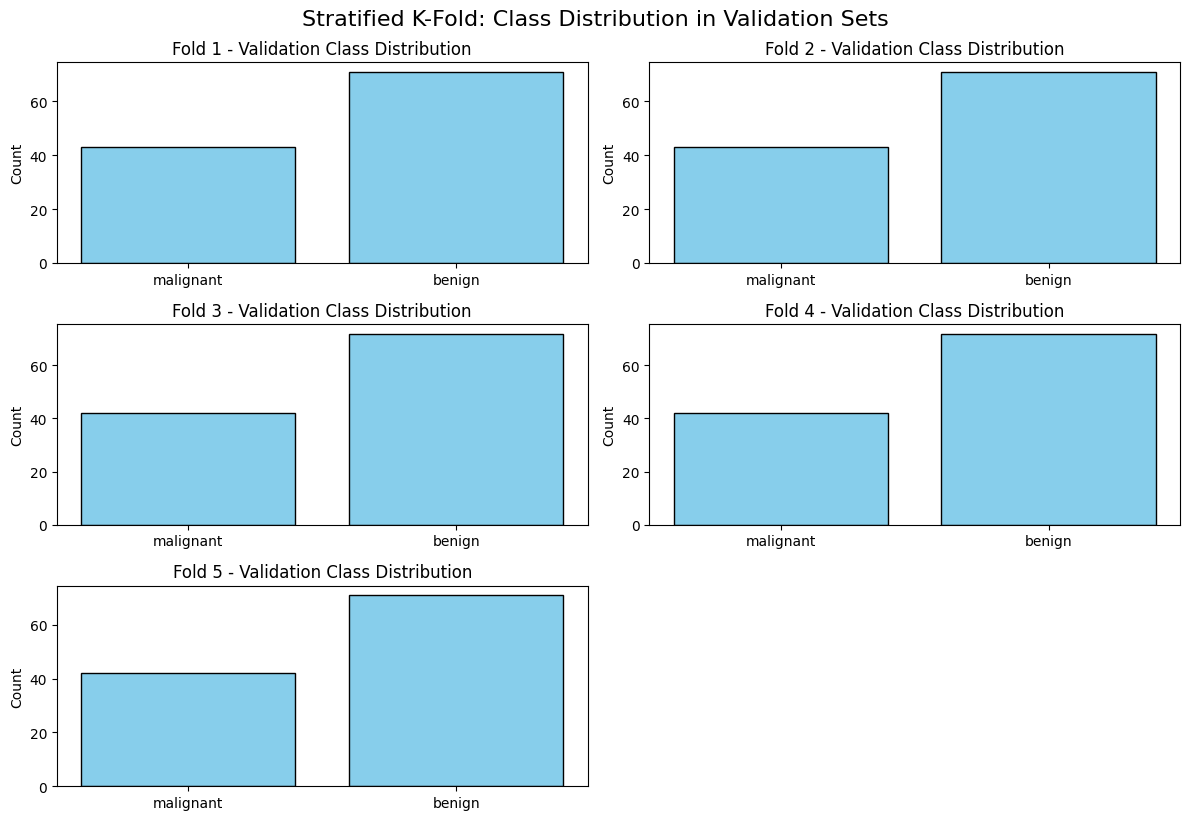

In [ ]:
# Visualize class distribution in each validation fold
plt.figure(figsize=(12, 8))

for i, (train_idx, val_idx) in enumerate(folds):
    y_val = y_class[val_idx]
    classes, counts = np.unique(y_val, return_counts=True)

    plt.subplot(3, 2, i+1)
    plt.bar(classes, counts, color='skyblue', edgecolor='black')
    plt.xticks(classes, class_names)
    plt.title(f"Fold {i+1} - Validation Class Distribution")
    plt.ylabel("Count")

plt.tight_layout()
plt.suptitle("Stratified K-Fold: Class Distribution in Validation Sets", fontsize=16, y=1.02)
plt.show()


### **Explanation & Justification**

* We use `StratifiedKFold` with 5 splits to ensure each fold mirrors the original class distribution.
* **Why important?**

  * In imbalanced datasets, normal `KFold` might create folds where a minority class is underrepresented or absent.
  * This could lead to biased training or misleading validation performance.
* **Visual Output**:

  * Each bar chart shows how many samples of each class are in that fold’s validation set.
  * You should observe **near-identical class proportions** across all folds.



## Leave-One-Out Cross-Validation (LOOCV)

In **Leave-One-Out Cross-Validation**, the number of folds is equal to the number of samples.

- For each iteration:
  - One sample is used as the **validation set**.
  - All remaining samples form the **training set**.
- This results in very **high training cost**, but provides an **almost unbiased estimate** of generalization performance.

Use LOOCV for:
- **Small datasets**
- **Stable performance evaluation**

Let’s demonstrate how this works and verify the accuracy.


In [ ]:
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_breast_cancer
import numpy as np

# Load dataset
data = load_breast_cancer()
X_loocv = data.data
y_loocv = data.target

# Initialize model
model = LogisticRegression(max_iter=1000)

# Apply Leave-One-Out CV
loo = LeaveOneOut()
scores = cross_val_score(model, X_loocv, y_loocv, cv=loo, scoring='accuracy')

# Results
print("Number of samples:", len(scores))
print("Average Accuracy from LOOCV:", np.mean(scores))


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Number of samples: 569
Average Accuracy from LOOCV: 0.9507908611599297


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

### **Explanation & Justification**

* We use `LeaveOneOut()` which generates as many train-test splits as the number of data points.
* Each iteration trains on `n-1` samples and tests on the 1 remaining sample.
* This gives the **most exhaustive validation** and is often used when data is **limited in size**.
* **Drawback**: Computation time is high for large datasets, but in our case (569 samples) it is manageable.


## Repeated K-Fold Cross-Validation

**Repeated K-Fold** is an extension of **K-Fold Cross-Validation**, where the K-Fold procedure is repeated multiple times with different random splits.

Why use Repeated K-Fold?
- Reduces **variance** in performance estimates.
- Gives a more **robust average** metric by aggregating results across repetitions.

Parameters:
- `n_splits`: Number of folds in K-Fold.
- `n_repeats`: Number of times to repeat the K-Fold process.

Let’s visualize the distribution of validation sample indices across all folds and repeats.


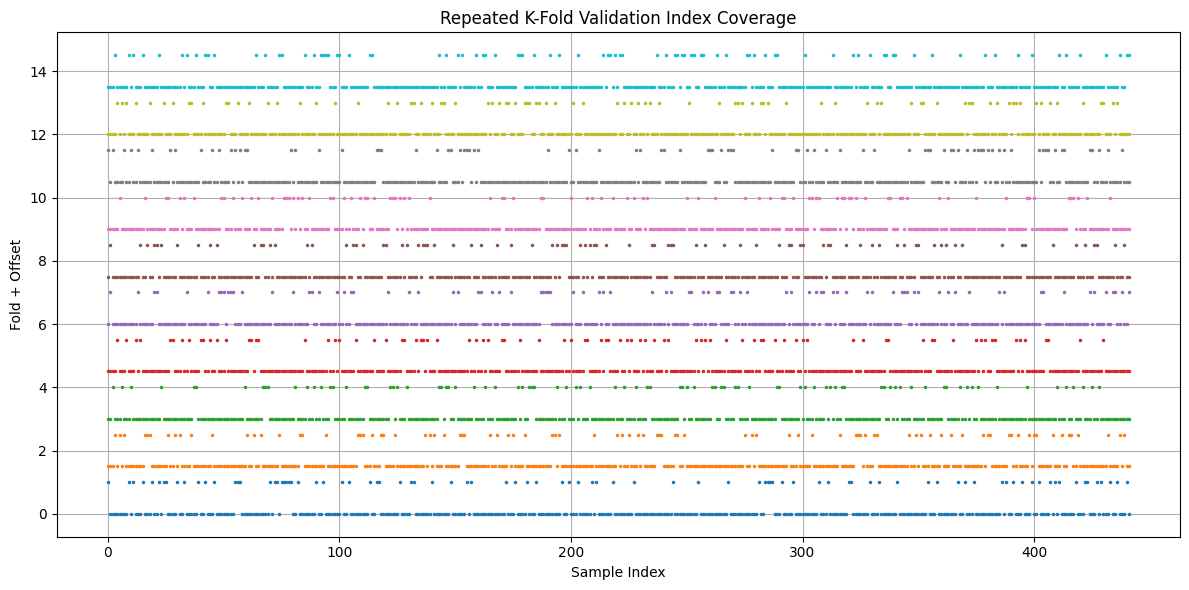

In [ ]:
from sklearn.model_selection import RepeatedKFold
import matplotlib.pyplot as plt
import numpy as np

# Load a small dataset
from sklearn.datasets import load_diabetes
X_rkf, y_rkf = load_diabetes(return_X_y=True)

# Initialize repeated k-fold
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

# Track validation indices per fold and repetition
plt.figure(figsize=(12, 6))

for fold, (train_index, val_index) in enumerate(rkf.split(X_rkf)):
    y_vals = np.zeros_like(y_rkf)
    y_vals[val_index] = 1  # mark validation indices
    plt.plot(y_vals + fold * 1.5, '.', label=f'Fold {fold+1}', markersize=3)

plt.title("Repeated K-Fold Validation Index Coverage")
plt.xlabel("Sample Index")
plt.ylabel("Fold + Offset")
plt.grid(True)
plt.tight_layout()
plt.show()
